In [ ]:
# import knihoven
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from uncertainties import ufloat as uf
from scipy.optimize import curve_fit
from pathlib import Path

# path config
downloads_dir = Path.home() / "Downloads"
# ujistime se, ze slozka existuje (kdyby nahodou ne)
downloads_dir.mkdir(parents=True, exist_ok=True)
# output_path = downloads_dir / 'muj_graf.png'

In [ ]:
# definice funkci

# nejistoty typu B pro digitalni pristroje
def unc_B_digital(reading, percent_reading, digits, resolution):    # vse musi byt ve spravnych jednotkach; funguje pouze pro jedny podminky zaroven
    """
    Vypocet nejistoty typu B pro digitalni mereni (ponechame krajni)

    reading : float nebo array
        namerena hodnota
    percent_reading : float
        % of reading
    digits : float
        pocet digitu
    resolution : float
        nejmensi dilek
    """

    max_error = abs(reading) * (percent_reading/100) + digits * resolution  # max_error -- krajni nejistota
    u_B = max_error

    return u_B

# nejistota typu A 
def unc_A(data):
    """
    Výpočet nejistoty typu A
    data : list nebo numpy array
         měření
    return : float
        nejistota typu A
    """
    data = np.array(data)
    n = len(data)

    s = np.std(data, ddof=1)
    u_A = s / np.sqrt(n)
    
    return u_A

In [ ]:
# nacteni google tabulek
sheet_id = '1ZebyvJcuBFii-uzZ6osOv-0ed3yA30mExWTFgEetvO8'
gid = '0'
url = f'https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid}'

df_odraz = pd.read_csv(url)

1.4550090286724449
[1.44632277 1.44575037 1.44324001 1.43616079 1.43391153 1.40521708
 1.43793922]


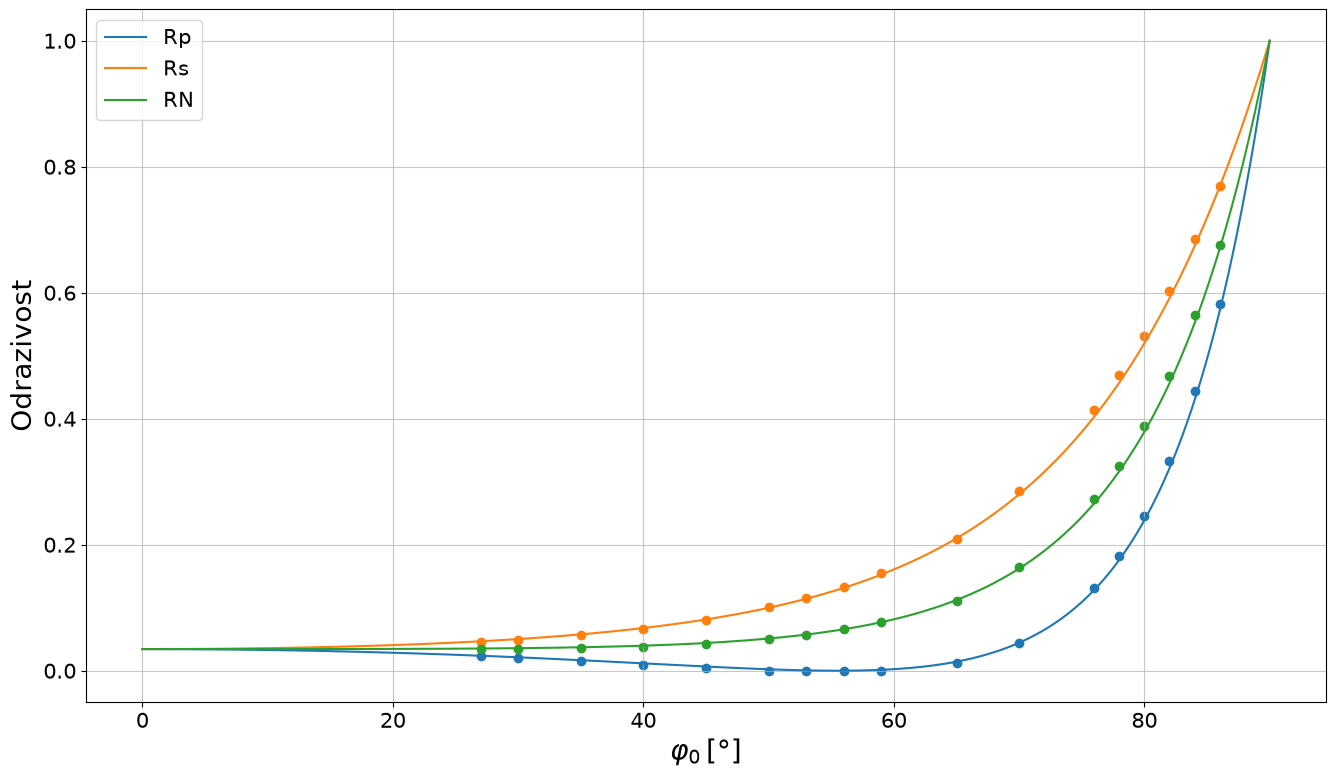

In [80]:
# odraz
phi0 = np.array(df_odraz['phi0'])*np.pi/180
Ip = np.array(df_odraz['Ip'])
Is = np.array(df_odraz['Is'])
Ip0 = np.array(df_odraz['Ip0'].iloc[0])
Is0 = np.array(df_odraz['Is0'].iloc[0])

Rp = Ip / Ip0
Rs = Is / Is0
RN = (Rp+Rs)/2

phiB = (55.50)*np.pi/180
phiB_unc = uf(phiB, 1)

n_n = np.tan(phiB)
print(n_n)

n_porov = (((1+Rs**0.5)*(1+Rp**0.5))/((1-Rs**0.5)*(1-Rp**0.5)))**0.5
n_porov = n_porov[:7]
print(n_porov)
phi1 = 99.99
rp = -((np.tan(phi0-phi1))/(np.tan(phi0+phi1)))

phi0_fit = np.linspace(0,90,1000)*np.pi/180
sin_phi1 = np.sin(phi0_fit)/n_n
cos_phi1 = (1 - sin_phi1**2)**0.5
rp_graf = (cos_phi1 - n_n*np.cos(phi0_fit))/(cos_phi1 + n_n*np.cos(phi0_fit))
rs_graf = (np.cos(phi0_fit) - n_n*cos_phi1)/(np.cos(phi0_fit) + n_n*cos_phi1)
rN_graf = (rp_graf**2 + rs_graf**2)/2

fig, ax = plt.subplots(figsize=(16, 9))
ax.set_ylabel(fr"Odrazivost", fontsize=20)
ax.set_xlabel(fr"$\varphi_0\,[°]$", fontsize=20)
ax.scatter(phi0*180/np.pi, Rp)
ax.scatter(phi0*180/np.pi, Rs)
ax.scatter(phi0*180/np.pi, RN)
ax.plot(phi0_fit*180/np.pi, rp_graf**2, label='Rp')
ax.plot(phi0_fit*180/np.pi, rs_graf**2, label='Rs')
ax.plot(phi0_fit*180/np.pi, rN_graf, label='RN')
ax.tick_params(labelsize=15)
ax.grid(True, alpha=0.7)
ax.legend(fontsize=15)
path_odr = downloads_dir / 'odrazivost.png'
plt.savefig(path_odr, dpi=300, bbox_inches='tight')

In [ ]:
# brewster

phib = np.array(df_odraz['phiB'])
U_B = np.array(df_odraz['U_B'])

fig, ax = plt.subplots(figsize=(16, 9))
ax.set_ylabel(fr"$U\,[mV]$", fontsize=20)
ax.set_xlabel(fr"$\varphi_0\,[°]$", fontsize=20)
ax.scatter(phib, U_B, label='Hodnoty')
ax.tick_params(labelsize=15)
ax.grid(True, alpha=0.7)
ax.legend(fontsize=15)
path_phiB = downloads_dir / 'brewster.png'
plt.savefig(path_phiB, dpi=300, bbox_inches='tight')

In [ ]:
# nacteni google tabulek
sheet_id = '1ZebyvJcuBFii-uzZ6osOv-0ed3yA30mExWTFgEetvO8'
gid = '641439416'
url = f'https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid}'

df_paral = pd.read_csv(url)


In [ ]:
# planparalelni deska
alpha = np.array(df_paral['alpha'])*np.pi/180
x = np.array(df_paral['x'])
d = np.array(df_paral['d'].dropna())

d = uf(np.mean(d), unc_A(d))
d_fit = d.n
n_deska = 1*(np.sin(alpha)**2 + ((1-(x/(d*np.sin(alpha))))**(-2))*np.cos(alpha)**2)**0.5
n_deska_fit = np.mean(1*(np.sin(alpha)**2 + ((1-(x/(d_fit*np.sin(alpha))))**(-2))*np.cos(alpha)**2)**0.5)
alpha_fit = np.linspace(0,50,1000)*np.pi/180
#alpha = alpha_fit
x_func = d.n*np.sin(alpha_fit)*(1-(np.cos(alpha_fit)/((n_deska_fit**2 - np.sin(alpha_fit)**2)**0.5)))

fig, ax = plt.subplots(figsize=(16, 9))
ax.set_ylabel(fr"$x\,[m]$", fontsize=20)
ax.set_xlabel(fr"$\alpha\,[°]$", fontsize=20)
ax.scatter(alpha*180/np.pi, x, label='hodnoty')
ax.plot(alpha_fit*180/np.pi, x_func, label='funkce')
ax.tick_params(labelsize=15)
ax.grid(True, alpha=0.7)
ax.legend(fontsize=15)
path_lom = downloads_dir / 'lom_deska.png'
plt.savefig(path_lom, dpi=300, bbox_inches='tight')